# Data-quality gates: staging, policy, and previewable remediation

The worst place to discover a broken vendor file is in the P&L meeting.
The pattern that prevents it is old ETL wisdom with a versioned twist:
**land every delivery in a staging table, run gates, and only promote to
production on pass**. h5i-db makes each step defensible — the raw broken
delivery stays on record as a staging version (evidence, not embarrassment),
the fix goes through a previewable plan/apply mutation with before/after
samples, and a database-level policy makes direct destructive writes
*impossible to do casually*, for humans and pipeline agents alike.

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa
import h5i_db

import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("prod_dq"), create=True)

## 1. Production history and a staging table

A 20-name universe with ~1 year of daily closes in `prices_prod`. The
vendor's next file will land in `vendor_staging` — same schema, separate
table, so nothing unvetted ever touches production.

In [2]:
UNIVERSE = [f"STK{i:03d}" for i in range(20)]
panel = cu.make_daily_prices(symbols=UNIVERSE, days=250).to_pandas()

sessions = np.sort(panel["ts"].unique())
delivery_ts = sessions[-1]                      # today's file
history = panel[panel["ts"] < delivery_ts]
delivery_true = panel[panel["ts"] == delivery_ts]  # what the vendor SHOULD send

schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("close", pa.float64()),
        pa.field("volume", pa.int64()),
    ]
)
cols = ["ts", "symbol", "close", "volume"]
for t in ("prices_prod", "vendor_staging"):
    db.create_table(t, schema, time_column="ts", sort_key=["ts", "symbol"])

db.append(
    "prices_prod",
    pa.Table.from_pandas(history[cols].sort_values(["ts", "symbol"]), schema=schema,
                         preserve_index=False),
    note="production history backfill",
)
db.sql("SELECT count(*) AS rows, count(DISTINCT ts) AS sessions FROM prices_prod").to_pandas()

,rows,sessions
0,4980,249


## 2. Lock the database down first

`set_policy` flips database-wide flags gating the *direct* mutation paths.
With `direct_write` / `direct_delete` off, restatements and deletions must
go through the plan/apply flow — previewed, noted, and conflict-checked —
while plain `append` (the only thing an ingest job should ever do) stays
open. This is the guardrail you want when pipelines are driven by cron jobs
or LLM agents: the destructive path simply isn't callable. (In the Python
API deletes are plan-only already; the flag also covers CLI and future
direct paths.)

In [3]:
db.set_policy(direct_write=False, direct_delete=False)

{'direct_append': True,
 'direct_write': False,
 'direct_replace': True,
 'direct_delete': False,
 'direct_restore': True,
 'direct_compact': True}

## 3. Today's delivery is broken four ways

The vendor file: half the universe missing, one negative price, one null,
and two duplicated rows. We land it in staging as-is — the raw file becomes
an immutable staging version, which is exactly what you want to show the
vendor when you open the ticket.

In [4]:
corrupt = delivery_true[delivery_true["symbol"].isin(UNIVERSE[:10])].copy()
corrupt.loc[corrupt.index[2], "close"] = -1.0          # sign-flip fat finger
corrupt.loc[corrupt.index[5], "close"] = np.nan        # null print
corrupt = pd.concat([corrupt, corrupt.iloc[[7, 8]]])   # duplicated rows

db.append(
    "vendor_staging",
    pa.Table.from_pandas(corrupt[cols].sort_values(["ts", "symbol"]), schema=schema,
                         preserve_index=False),
    note=f"vendor delivery {pd.Timestamp(delivery_ts).date()} (raw, unvetted)",
)
corrupt[cols].head(8)

,ts,symbol,close,volume
4980,2023-12-15 20:00:00+00:00,STK000,63.27,835178
4981,2023-12-15 20:00:00+00:00,STK001,403.93,258070
4982,2023-12-15 20:00:00+00:00,STK002,-1.00,630303
4983,2023-12-15 20:00:00+00:00,STK003,143.29,287608
4984,2023-12-15 20:00:00+00:00,STK004,198.19,302340
4985,2023-12-15 20:00:00+00:00,STK005,NaN,602331
4986,2023-12-15 20:00:00+00:00,STK006,85.64,207796
4987,2023-12-15 20:00:00+00:00,STK007,173.72,721503


## 4. The gate: five checks, all SQL on staging

Completeness against the expected universe, null and price sanity,
duplicate detection, and a row-count check against the trailing 20-session
average in production (a cheap but effective "did the vendor send half a
file" alarm). Every check reads the *staging table's current version* — the
gate result is reproducible against that version forever.

In [5]:
def run_gate(day: str) -> pd.DataFrame:
    stat = db.sql(
        f"""
        SELECT count(*)                                 AS rows,
               count(DISTINCT symbol)                   AS symbols,
               sum(CASE WHEN close IS NULL THEN 1 ELSE 0 END) AS null_closes,
               min(close)                               AS px_min
        FROM vendor_staging
        WHERE ts >= '{day}T00:00:00Z' AND ts < '{day}T23:59:59Z'
        """
    ).to_pandas().iloc[0]
    trailing = db.sql(
        """
        SELECT avg(n) AS avg_rows FROM (
            SELECT ts, count(*) AS n FROM prices_prod GROUP BY ts ORDER BY ts DESC LIMIT 20
        )
        """
    ).to_pandas()["avg_rows"].iloc[0]

    rows, symbols = int(stat["rows"]), int(stat["symbols"])
    checks = [
        ("universe complete", symbols == len(UNIVERSE), f"{symbols}/{len(UNIVERSE)} symbols"),
        ("no null prices", int(stat["null_closes"]) == 0, f"{int(stat['null_closes'])} nulls"),
        ("prices positive", bool(stat["px_min"] > 0), f"min close {stat['px_min']}"),
        ("no duplicate rows", rows == symbols, f"{rows} rows / {symbols} distinct"),
        ("row count vs history", abs(rows - trailing) / trailing < 0.2,
         f"{rows} vs trailing avg {trailing:.0f}"),
    ]
    return pd.DataFrame(checks, columns=["check", "passed", "detail"])

day = str(pd.Timestamp(delivery_ts).date())
gate_raw = run_gate(day)
print(f"gate verdict: {'PROMOTE' if gate_raw['passed'].all() else 'REJECT - hold in staging'}")
gate_raw

gate verdict: REJECT - hold in staging


,check,passed,detail
0,universe complete,False,10/20 symbols
1,no null prices,False,1 nulls
2,prices positive,False,min close -1.0
3,no duplicate rows,False,12 rows / 10 distinct
4,row count vs history,False,12 vs trailing avg 20


## 5. The shortcut that policy makes impossible

The tempting fix: "just overwrite staging with the corrected file". With
`direct_write` off, that path raises `PolicyError` — the error's hint
points at the sanctioned flow. Nobody fixes production data at 2am with an
unreviewed `write()` again.

In [6]:
fixed = pa.Table.from_pandas(delivery_true[cols].sort_values(["ts", "symbol"]),
                             schema=schema, preserve_index=False)
try:
    db.write("vendor_staging", fixed)
except h5i_db.PolicyError as e:
    print(f"PolicyError  code={e.code}  retryable={e.retryable}")
    print(f"hint: {e.hint}")

PolicyError  code=policy_violation  retryable=False
hint: run the write with --plan to preview it, review, then `h5i-db plan apply`; or relax the policy with `h5i-db policy set`


## 6. Remediation the sanctioned way: plan, inspect, apply

`plan_replace_range` stages the corrected delivery over the broken day's
window (range bounds are raw **microseconds** in the time column's unit).
The plan is not a commit: it carries a summary and before/after samples you
can eyeball — or attach to the change ticket — before `apply()` publishes
it atomically. Applying is conflict-checked: if anyone commits to staging
in between, apply fails instead of clobbering.

In [7]:
day_start_us = int(pd.Timestamp(delivery_ts).value // 1000)
plan = db.plan_replace_range(
    "vendor_staging", day_start_us, day_start_us + 1,
    data=fixed, note=f"vendor re-delivery {day}: full universe, corrected prices",
)
plan.summary

{'rows_before': 12,
 'rows_after': 20,
 'rows_affected': 12,
 'segments_reused': 0,
 'segments_added': 1,
 'added_bytes': 1816,
 'affected_time_range': [1702670400000000, 1702670400000001]}

In [8]:
print("BEFORE (broken rows in the affected window):")
print(plan.before_sample.to_pandas().head(6).to_string(index=False))
print("\nAFTER (corrected delivery):")
print(plan.after_sample.to_pandas().head(6).to_string(index=False))

BEFORE (broken rows in the affected window):
                       ts symbol  close  volume
2023-12-15 20:00:00+00:00 STK000  63.27  835178
2023-12-15 20:00:00+00:00 STK001 403.93  258070
2023-12-15 20:00:00+00:00 STK002  -1.00  630303
2023-12-15 20:00:00+00:00 STK003 143.29  287608
2023-12-15 20:00:00+00:00 STK004 198.19  302340
2023-12-15 20:00:00+00:00 STK005    NaN  602331

AFTER (corrected delivery):
                       ts symbol  close  volume
2023-12-15 20:00:00+00:00 STK000  63.27  835178
2023-12-15 20:00:00+00:00 STK001 403.93  258070
2023-12-15 20:00:00+00:00 STK002 157.64  630303
2023-12-15 20:00:00+00:00 STK003 143.29  287608
2023-12-15 20:00:00+00:00 STK004 198.19  302340
2023-12-15 20:00:00+00:00 STK005  23.48  602331


In [9]:
result = plan.apply()
{k: result[k] for k in ("sequence", "op", "rows_total")}

{'sequence': 2, 'op': 'replace_range', 'rows_total': 20}

## 7. Re-run the gate, then promote

The gate now passes, so the delivery-day rows are appended to production —
with a note tying the promotion to the gated delivery. Both tables' version
histories together tell the whole story: raw broken file, previewed fix,
gated promotion.

In [10]:
gate_fixed = run_gate(day)
assert gate_fixed["passed"].all(), "gate must pass after remediation"
print("gate verdict: PROMOTE")

staged = db.sql(
    f"SELECT ts, symbol, close, volume FROM vendor_staging "
    f"WHERE ts >= '{day}T00:00:00Z' ORDER BY ts, symbol"
).to_arrow()
db.append("prices_prod", staged.cast(schema), note=f"promoted gated delivery {day}")

[
    {k: v.get(k) for k in ("sequence", "op", "rows", "note")}
    for v in db.versions("vendor_staging") + db.versions("prices_prod")
    if v["op"] != "create"
]

gate verdict: PROMOTE


[{'sequence': 1,
  'op': 'append',
  'rows': 12,
  'note': 'vendor delivery 2023-12-15 (raw, unvetted)'},
 {'sequence': 2,
  'op': 'replace_range',
  'rows': 20,
  'note': 'vendor re-delivery 2023-12-15: full universe, corrected prices'},
 {'sequence': 1,
  'op': 'append',
  'rows': 4980,
  'note': 'production history backfill'},
 {'sequence': 2,
  'op': 'append',
  'rows': 5000,
  'note': 'promoted gated delivery 2023-12-15'}]

## 8. The gate report, dashboard-style

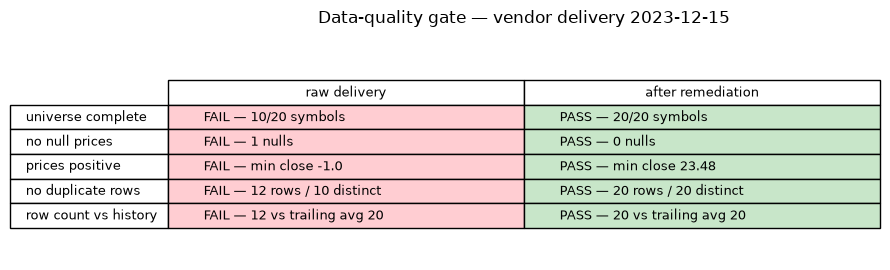

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.axis("off")
col_labels = ["raw delivery", "after remediation"]
cell_text, cell_colors = [], []
for i in range(len(gate_raw)):
    row_text, row_colors = [], []
    for g in (gate_raw, gate_fixed):
        ok = bool(g.loc[i, "passed"])
        row_text.append(("PASS — " if ok else "FAIL — ") + g.loc[i, "detail"])
        row_colors.append("#c8e6c9" if ok else "#ffcdd2")
    cell_text.append(row_text)
    cell_colors.append(row_colors)

tbl = ax.table(cellText=cell_text, cellColours=cell_colors,
               rowLabels=gate_raw["check"].tolist(), colLabels=col_labels,
               loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)
ax.set_title(f"Data-quality gate — vendor delivery {day}", pad=18)
fig.tight_layout()

## Takeaways

- Staging + gate + promote is the pattern; h5i-db adds the receipts. The
  broken raw file, the previewed fix, and the promotion are all *versions
  with notes* — the incident report writes itself from `versions()`.
- `set_policy(direct_write=False, direct_delete=False)` turns "please don't
  hot-fix production" from a convention into a `PolicyError`. Appends stay
  open, so ingest keeps flowing.
- `plan_replace_range` gives you a dry-run with `summary` and
  before/after samples, then an atomic, conflict-checked `apply()`.
  Remember: plan range bounds are raw microseconds.
- The row-count-vs-trailing-history check is the cheapest gate with the
  highest catch rate — half-files and double-sends are far more common than
  subtle corruption.

In [12]:
db.close()